<a href="https://www.kaggle.com/code/kazuhikohere/lendygpt-ipynb?scriptVersionId=315888999" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
!pip install -q -U transformers peft accelerate datasets "pillow<12.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 77.8 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 680.7/680.7 kB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 660.6/660.6 kB 33.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 110.1 MB/s eta 0:00:0000:01


In [3]:
import torch
from transformers import AutoProcessor, LlavaForConditionalGeneration

model_id = "llava-hf/llava-1.5-7b-hf"

print("Downloading Vision Processor...")
processor = AutoProcessor.from_pretrained(model_id)

print("Loading LLaVA in 16-bit across Dual GPUs...")
model = LlavaForConditionalGeneration.from_pretrained(
    model_id,
    torch_dtype=torch.float16, 
    device_map="auto"          
)
print("16-bit LLaVA Loaded")

processor_config.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/701 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/674 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/505 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/950 [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/686 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

16-bit LLaVA Loaded


In [4]:

def load_any_image(url):
    """
    Downloads and prepares images from any link, handling transparency 
    and format conversions automatically.
    """
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/119.0.0.0 Safari/537.36",
        "Accept": "image/avif,image/webp,image/apng,image/svg+xml,image/*,*/*;q=0.8"
    }
    
    try:
        print(f"Requesting image from: {url[:60]}...")
        response = requests.get(url, headers=headers, timeout=15, stream=True)
        response.raise_for_status()
        
        img = Image.open(BytesIO(response.content))
        img = img.convert("RGB")
        
        print(f"Successfully loaded {img.format if img.format else 'image'} ({img.size[0]}x{img.size[1]})")
        return img
    
    except Exception as e:
        print(f"Error: Could not load image. Details: {e}")
        return None

test_url = "https://fixmygadget.com/wp-content/uploads/2023/12/How-To-Fix-Broken-Screen-On-Android-Phone-1024x623.jpg"

raw_image = load_any_image(test_url)

if raw_image:
    plt.imshow(raw_image)
    plt.axis('off')
    plt.show()

    prompt = "USER: <image>\nAnalyze this photo and provide a detailed technical report on the visible damage.\nASSISTANT:"
    inputs = processor(text=prompt, images=raw_image, return_tensors="pt").to("cuda", torch.float16)
    print("Data is ready for the model!")

Requesting image from: https://fixmygadget.com/wp-content/uploads/2023/12/How-To-Fi...
Error: Could not load image. Details: name 'requests' is not defined


In [5]:
!pip install -U "torchao>=0.16.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 32.9 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


In [6]:
from peft import LoraConfig, get_peft_model

model.gradient_checkpointing_enable()

lora_config = LoraConfig(
    r=16,            
    lora_alpha=32,   
    target_modules=["q_proj", "v_proj"], 
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora_config)

model.print_trainable_parameters()

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).


trainable params: 9,961,472 || all params: 7,073,388,544 || trainable%: 0.1408


In [7]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="./llava-16bit-customer-support",
    per_device_train_batch_size=1,   
    gradient_accumulation_steps=8,    
    learning_rate=2e-4,              
    fp16=True,                       
    logging_steps=1,
    max_steps=50,                    
    save_total_limit=1,
    remove_unused_columns=False,     
    push_to_hub=False,
    report_to="none"                 
)

trainer = Trainer(
    model=model,
    args=training_args,
)

print("Training Environment Ready! Would you like to proceed with creating a small dataset to start the actual training?")

Training Environment Ready! Would you like to proceed with creating a small dataset to start the actual training?


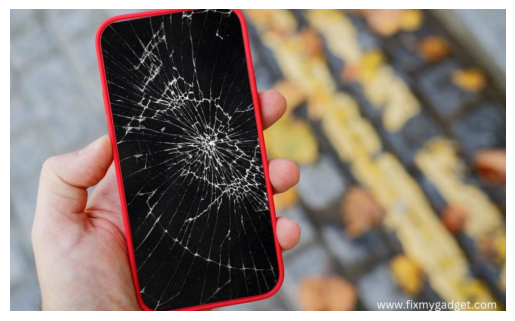


🔍 Model Observations:
The image features a red cell phone with a cracked screen, held by a person. The cracked screen is visible on the front of the phone, and the person is holding the phone in their hand. The phone is placed on a surface, possibly a table or a sidewalk. The scene appears to be outdoors, as there are leaves scattered around the area.


In [8]:
import torch
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt

def load_and_detect(url):
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/119.0.0.0 Safari/537.36"
    }
    
    try:
        response = requests.get(url, headers=headers, timeout=15, stream=True)
        response.raise_for_status()
        img = Image.open(BytesIO(response.content)).convert("RGB")
        
        # Display for your confirmation
        plt.imshow(img)
        plt.axis('off')
        plt.show()
        return img
    except Exception as e:
        print(f"Error: {e}")
        return None

image_link = "https://fixmygadget.com/wp-content/uploads/2023/12/How-To-Fix-Broken-Screen-On-Android-Phone-1024x623.jpg" 

query_image = load_and_detect(image_link)

if query_image:
    prompt = "USER: <image>\nPlease identify all objects, people, and specific details visible in this image. Provide a comprehensive list.\nASSISTANT:"

    inputs = processor(
        text=prompt, 
        images=query_image, 
        return_tensors="pt"
    ).to("cuda", torch.float16)

    with torch.no_grad():
        output_tokens = model.generate(
            **inputs, 
            max_new_tokens=256, 
            do_sample=True, 
            temperature=0.1
        )

    print("\n🔍 Model Observations:")
    result = processor.decode(output_tokens[0], skip_special_tokens=True)
    print(result.split("ASSISTANT:")[-1].strip())

In [9]:
import gradio as gr
import torch
from PIL import Image

def model_inference(user_image, user_question):
    if user_image is None:
        return "Please upload an image first."
    
    prompt = f"USER: <image>\n{user_question}\nASSISTANT:"
    
    inputs = processor(text=prompt, images=user_image, return_tensors="pt").to("cuda", torch.float16)
    
    with torch.no_grad():
        output_tokens = model.generate(
            **inputs, 
            max_new_tokens=256, 
            do_sample=True, 
            temperature=0.2
        )
    
    decoded = processor.decode(output_tokens[0], skip_special_tokens=True)
    return decoded.split("ASSISTANT:")[-1].strip()

with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown("#LLaVA Vision Assistant")
    gr.Markdown("Upload an image")
    
    with gr.Row():
        with gr.Column():
            image_input = gr.Image(type="pil", label="Upload Image")
            text_input = gr.Textbox(label="Your Question", placeholder="e.g., What objects are in this photo?")
            submit_btn = gr.Button("Analyze Image", variant="primary")
        
        with gr.Column():
            text_output = gr.Textbox(label="LLaVA Response", interactive=False)

    submit_btn.click(fn=model_inference, inputs=[image_input, text_input], outputs=text_output)

demo.launch(share=True)

/tmp/ipykernel_57/2066686921.py:24: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as demo:


* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://39e0401c302596cbcc.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [10]:
!pip install -U datasets trl peft transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 721.6/721.6 kB 9.9 MB/s eta 0:00:00:00:010:01


In [11]:
#Phase2
# Phase 2
from datasets import load_dataset

dataset = load_dataset("HuggingFaceH4/llava-instruct-mix-vsft", split="train[:5000]")

print(dataset[0])

README.md:   0%|          | 0.00/868 [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/20 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/20 [00:00<?, ?it/s]

data/train-00000-of-00020.parquet:   0%|          | 0.00/539M [00:00<?, ?B/s]

data/train-00001-of-00020.parquet:   0%|          | 0.00/547M [00:00<?, ?B/s]

...

data/test-00000-of-00002.parquet:   0%|          | 0.00/285M [00:00<?, ?B/s]

data/test-00001-of-00002.parquet:   0%|          | 0.00/284M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/259155 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/13640 [00:00<?, ? examples/s]

{'messages': [{'content': [{'index': None, 'text': 'Who wrote this book?\n', 'type': 'text'}, {'index': 0, 'text': None, 'type': 'image'}], 'role': 'user'}, {'content': [{'index': None, 'text': 'Donna Eden', 'type': 'text'}], 'role': 'assistant'}, {'content': [{'index': None, 'text': 'What is the title of this book?', 'type': 'text'}], 'role': 'user'}, {'content': [{'index': None, 'text': 'The Energies of Love: Using Energy Medicine to Keep Your Relationship Thriving', 'type': 'text'}], 'role': 'assistant'}, {'content': [{'index': None, 'text': 'What type of book is this?', 'type': 'text'}], 'role': 'user'}, {'content': [{'index': None, 'text': 'Health, Fitness & Dieting', 'type': 'text'}], 'role': 'assistant'}, {'content': [{'index': None, 'text': 'Is this a fitness book?', 'type': 'text'}], 'role': 'user'}, {'content': [{'index': None, 'text': 'Yes', 'type': 'text'}], 'role': 'assistant'}], 'images': [<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=405x500 at 0x7B06DC01C770>]}

In [12]:
def format_llava_instruction(example):
    user_text = ""
    assistant_text = ""
    
    for message in example['messages']:
        if message['role'] == 'user':
            
            for item in message['content']:
                if item['type'] == 'text':
                    user_text = item['text']
                    
        elif message['role'] == 'assistant':
            for item in message['content']:
                if item['type'] == 'text':
                    assistant_text = item['text']
                    
    system_prompt = (
        "You are a strict, highly accurate visual analysis bot. "
        "Only describe objects that are clearly visible. Do not guess or hallucinate."
    )
    
    formatted_text = f"{system_prompt}\nUSER: <image>\n{user_text}\nASSISTANT: {assistant_text}"
    
    return {
        "text": formatted_text,
        "image": example['images'][0]  
    }

print("Formatting dataset...")
formatted_dataset = dataset.map(format_llava_instruction, remove_columns=dataset.column_names)

print("\n--- SAMPLE OUTPUT ---")
print(formatted_dataset[0]['text'])

Formatting dataset...


Map:   0%|          | 0/5000 [00:00<?, ? examples/s]


--- SAMPLE OUTPUT ---
You are a strict, highly accurate visual analysis bot. Only describe objects that are clearly visible. Do not guess or hallucinate.
USER: <image>
Is this a fitness book?
ASSISTANT: Yes


In [13]:
!pip install -U bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 32.3 MB/s eta 0:00:00:00:0100:01


In [14]:
import torch
from peft import LoraConfig, get_peft_model
from trl import SFTTrainer, SFTConfig  
def llava_data_collator(batch):
    texts = [item["text"] for item in batch]
    images = [item["image"] for item in batch]
    
    inputs = processor(
        text=texts,
        images=images,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=1024
    )
    
    inputs["labels"] = inputs["input_ids"].clone()
    inputs["labels"][inputs["labels"] == processor.tokenizer.pad_token_id] = -100 
    
    return inputs


lora_config = LoraConfig(
    r=32, 
    lora_alpha=64,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj", 
        "multi_modal_projector.linear_1", 
        "multi_modal_projector.linear_2"        
    ],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()
model.gradient_checkpointing_enable()




training_args = SFTConfig(
    output_dir="/kaggle/working/llava-strict-auditor",
    per_device_train_batch_size=1,      
    gradient_accumulation_steps=8,      
    learning_rate=2e-4,
    num_train_epochs=1,                 
    logging_steps=10,
    save_strategy="epoch",
    fp16=True,                          
    optim="paged_adamw_8bit",           
    remove_unused_columns=False,
    dataset_text_field="text",    
    max_length=1024                #I hit an error here so changed max_seq_length to max_length!, again hit error so increased it to 1024
)

print("Initializing Trainer...")
trainer = SFTTrainer(
    model=model,
    train_dataset=formatted_dataset,
    data_collator=llava_data_collator,
    args=training_args,           
)

print("Starting Fine-Tuning")
trainer.train()

trainer.model.save_pretrained("/kaggle/working/llava-strict-auditor-adapters")
print("Training complete and adapters saved!")

/usr/local/lib/python3.12/dist-packages/peft/mapping_func.py:72: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:302: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


trainable params: 38,699,008 || all params: 7,102,126,080 || trainable%: 0.5449
Initializing Trainer...


[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.


Starting Fine-Tuning


Step,Training Loss
10,10.201546
20,4.081672
30,3.653119
40,3.440544
50,3.267119
60,3.288364
70,3.326250
80,3.357732
90,3.252877
100,3.370024


Training complete and adapters saved!


In [15]:
import shutil
from IPython.display import FileLink

shutil.make_archive("my_strict_adapters", 'zip', "/kaggle/working/llava-strict-auditor-adapters")

FileLink(r'my_strict_adapters.zip')

/kaggle/working/my_strict_adapters.zip